In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import tkinter
import matplotlib
from matplotlib.backends.backend_tkagg import *

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def select_scenario() -> Path:
    # Get all folder names from the logs folder
    logs_folder = Path(os.path.abspath('')) / 'logs'
    scenarios = [folder for folder in logs_folder.iterdir() if folder.is_dir()]
    print('Select a scenario:')
    for i, folder in enumerate(scenarios):
        print(f"[{i}]: {folder.name}")
    print("Your selection: ")
    selection = int(input())
    return scenarios[selection]

scenario_folder = select_scenario()

Select a scenario:
[0]: soil
Your selection: 


In [19]:
def node_to_node_distance(x1,y1,z1,x2,y2,z2):
    return ((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)**0.5

node_pos_df = pd.read_csv(scenario_folder / 'course_change.csv', delimiter=';', names=["Time","Type","ID","x","y","z"], index_col=False)
node_pos_df["Time"] = node_pos_df["Time"].str.replace('ns', '').astype(float)
node_pos_df.drop_duplicates(subset=["Time","ID"], keep='last', inplace=True)
node_pos_df.reset_index(drop=True, inplace=True)
node_pos_df

,Time,Type,ID,x,y,z
0,0.0,STA,0,0.4,0.4,-0.3
1,0.0,STA,1,1.2,0.4,-0.3
2,0.0,STA,2,2.0,0.4,-0.3
3,0.0,STA,3,2.8,0.4,-0.3
4,0.0,STA,4,3.6,0.4,-0.3
...,...,...,...,...,...,...
196,0.0,STA,196,1.2,10.8,-0.3
197,0.0,STA,197,2.0,10.8,-0.3
198,0.0,STA,198,2.8,10.8,-0.3
199,0.0,STA,199,3.6,10.8,-0.3


In [20]:
rx_packets_df_col_names = [
    "Time",
    "Packet UID",
    "Packet size",
    "Channel freq",
    "Channel no", 
    "Rate", 
    "Is short preamble",
    "Rx sniffer node ID",
    "Receiver MAC",
    "Receiver node ID", 
    "Transmitter MAC",
    "Transmitter node ID",
    "BSSID MAC",
    "BSSID node ID",
    "Destination MAC",
    "Destination node ID",
    "Source MAC",
    "Source node ID",
    "Mode", 
    "Retries",
    "Ness",
    "Nss",
    "Is short guard interval",
    "Is stbc",
    "Tx power level",
    "Noise",
    "Signal",
    "Is retry"
    ]
rx_packets_df = pd.read_csv(scenario_folder / 'monitor_sniffer_rx.csv', delimiter=';', names=rx_packets_df_col_names, index_col=False)
rx_packets_df["Time"] = rx_packets_df["Time"].str.replace('ns', '').astype(float)
rx_packets_df = rx_packets_df[rx_packets_df["Destination node ID"] != 4294967295]
rx_packets_df = rx_packets_df[rx_packets_df["Source node ID"] != 4294967295]
rx_packets_df

,Time,Packet UID,Packet size,Channel freq,Channel no,Rate,Is short preamble,Rx sniffer node ID,Receiver MAC,Receiver node ID,...,Mode,Retries,Ness,Nss,Is short guard interval,Is stbc,Tx power level,Noise,Signal,Is retry
0,5.093820e+08,36,102,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.976,-91.9598,True
2,5.118860e+08,68,75,905,1,131,False,168,00:00:00:00:00:a9,168,...,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-113.976,-75.9598,False
4,5.198061e+08,66,102,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.976,-95.7997,True
6,5.252062e+08,56,102,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.976,-94.2473,True
8,5.307102e+08,23,102,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.976,-90.3128,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14641,3.592909e+12,35721,103,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-113.976,-93.2485,False
14643,3.593246e+12,33155,103,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-113.976,-92.1839,False
14645,3.593531e+12,40110,103,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.976,-91.9598,True
14647,3.596560e+12,34854,103,905,1,131,False,200,00:00:00:00:00:c9,200,...,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-113.976,-93.6596,False


In [21]:
tx_packets_df_col_names = [
    "Time", 
    "Packet UID",
    "Packet size",
    "Channel freq",
    "Channel no", 
    "Rate", 
    "Is short preamble",
    "Tx sniffer node ID",
    "Receiver MAC",
    "Receiver node ID", 
    "Transmitter MAC",
    "Transmitter node ID",
    "BSSID MAC",
    "BSSID node ID",
    "Destination MAC",
    "Destination node ID",
    "Source MAC",
    "Source node ID",
    "Mode",
    "Retries",
    "Ness",
    "Nss",
    "Is short guard interval",
    "Is stbc",
    "Tx power level",
    "Is retry"
    ]
tx_packets_df = pd.read_csv(scenario_folder / 'monitor_sniffer_tx.csv', delimiter=';', names=tx_packets_df_col_names, index_col=False)
tx_packets_df["Time"] = tx_packets_df["Time"].str.replace('ns', '').astype(float)
tx_packets_df = tx_packets_df[tx_packets_df["Destination node ID"] != 4294967295]
tx_packets_df = tx_packets_df[tx_packets_df["Source node ID"] != 4294967295]
tx_packets_df

,Time,Packet UID,Packet size,Channel freq,Channel no,Rate,Is short preamble,Tx sniffer node ID,Receiver MAC,Receiver node ID,...,Source MAC,Source node ID,Mode,Retries,Ness,Nss,Is short guard interval,Is stbc,Tx power level,Is retry
5,5.027320e+08,5,102,905,1,131,False,128,00:00:00:00:00:c9,200,...,00:00:00:00:00:81,128,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False
6,5.027320e+08,6,102,905,1,131,False,82,00:00:00:00:00:c9,200,...,00:00:00:00:00:53,82,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False
7,5.027320e+08,7,102,905,1,131,False,95,00:00:00:00:00:c9,200,...,00:00:00:00:00:60,95,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False
8,5.027320e+08,8,102,905,1,131,False,114,00:00:00:00:00:c9,200,...,00:00:00:00:00:73,114,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False
9,5.027320e+08,9,102,905,1,131,False,129,00:00:00:00:00:c9,200,...,00:00:00:00:00:82,129,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53893,3.593244e+12,33155,103,905,1,131,False,40,00:00:00:00:00:c9,200,...,00:00:00:00:00:29,40,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False
53898,3.593525e+12,40110,103,905,1,131,False,168,00:00:00:00:00:c9,200,...,00:00:00:00:00:a9,168,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False
53899,3.593530e+12,40110,103,905,1,131,False,168,00:00:00:00:00:c9,200,...,00:00:00:00:00:a9,168,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,True
53930,3.596558e+12,34854,103,905,1,131,False,42,00:00:00:00:00:c9,200,...,00:00:00:00:00:2b,42,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,False


In [22]:
packet_stats_df = pd.DataFrame()
packet_stats_df['Sent packet count'] = tx_packets_df['Packet UID'].value_counts()
packet_stats_df['Received packet count'] = rx_packets_df['Packet UID'].value_counts()
packet_stats_df['Dropped packet count'] = packet_stats_df['Sent packet count'] - packet_stats_df['Received packet count']
packet_stats_df['First seen at'] = tx_packets_df.groupby('Packet UID')['Time'].min()
packet_stats_df['Received at'] = rx_packets_df.groupby('Packet UID')['Time'].max()
packet_stats_df['Latency'] = packet_stats_df['Received at'] - packet_stats_df['First seen at']
packet_stats_df['Source node ID'] = tx_packets_df.groupby('Packet UID')['Source node ID'].first()
packet_stats_df['Destination node ID'] = tx_packets_df.groupby('Packet UID')['Destination node ID'].first()

# Calculate the distance between the two nodes at the time of the most recent position update at the time of the first packet transmission
packet_stats_df['Distance'] = packet_stats_df.apply(lambda row: node_to_node_distance(
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['ID'] == row['Source node ID'])].iloc[-1]['x'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['ID'] == row['Source node ID'])].iloc[-1]['y'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['ID'] == row['Source node ID'])].iloc[-1]['z'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['ID'] == row['Destination node ID'])].iloc[-1]['x'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['ID'] == row['Destination node ID'])].iloc[-1]['y'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['ID'] == row['Destination node ID'])].iloc[-1]['z'],
), axis=1)

packet_stats_df

,Sent packet count,Received packet count,Dropped packet count,First seen at,Received at,Latency,Source node ID,Destination node ID,Distance
Packet UID,,,,,,,,,
12555,95,52,43,7.841214e+11,3.547128e+12,2.763007e+12,193,200,6.658078
16742,91,46,45,1.144121e+12,3.547169e+12,2.403047e+12,79,200,3.689173
11210,82,49,33,6.641214e+11,3.547663e+12,2.883542e+12,131,200,4.021194
8624,78,56,22,4.241214e+11,3.548071e+12,3.123950e+12,7,200,6.053924
6766,63,56,7,2.441214e+11,3.566059e+12,3.321937e+12,124,200,3.419064
...,...,...,...,...,...,...,...,...,...
3620,1,1,0,2.612028e+10,2.612148e+10,1.200010e+06,80,200,3.226453
3582,1,1,0,2.612326e+10,2.612446e+10,1.200016e+06,200,77,4.883646
583,1,1,0,2.673727e+09,2.674807e+09,1.080013e+06,200,64,4.100000


In [23]:
node_statistics_df = pd.DataFrame()
node_statistics_df['Node ID'] = node_pos_df['ID'].unique()
node_statistics_df.set_index('Node ID', inplace=True)
node_statistics_df['Node type'] = node_pos_df.groupby('ID')['Type'].first()
node_statistics_df['x'] = node_pos_df.groupby('ID')['x'].last()
node_statistics_df['y'] = node_pos_df.groupby('ID')['y'].last()
node_statistics_df['z'] = node_pos_df.groupby('ID')['z'].last()
node_statistics_df['Sent packet count'] = packet_stats_df.groupby('Source node ID')['Sent packet count'].sum()
node_statistics_df['Received packet count'] = packet_stats_df.groupby('Destination node ID')['Received packet count'].sum()
node_statistics_df['Dropped packet count'] = packet_stats_df.groupby('Source node ID')['Dropped packet count'].sum()
node_statistics_df['Average latency'] = packet_stats_df.groupby('Source node ID')['Latency'].mean()
node_statistics_df['Average signal strength'] = rx_packets_df.groupby('Receiver node ID')['Signal'].mean()
node_statistics_df

,Node type,x,y,z,Sent packet count,Received packet count,Dropped packet count,Average latency,Average signal strength
Node ID,,,,,,,,,
0,STA,0.4,0.4,-0.3,19,3,14,3.292034e+08,-80.389300
1,STA,1.2,0.4,-0.3,24,3,18,3.487850e+08,-79.799700
2,STA,2.0,0.4,-0.3,12,3,6,2.359151e+09,-79.231100
3,STA,2.8,0.4,-0.3,37,4,28,1.720378e+09,-78.704700
4,STA,3.6,0.4,-0.3,37,3,28,3.461049e+08,-78.247300
...,...,...,...,...,...,...,...,...,...
196,STA,1.2,10.8,-0.3,59,2,9,4.380685e+11,-79.119400
197,STA,2.0,10.8,-0.3,54,2,4,6.370587e+11,-78.449100
198,STA,2.8,10.8,-0.3,58,2,10,4.977316e+11,-77.813900


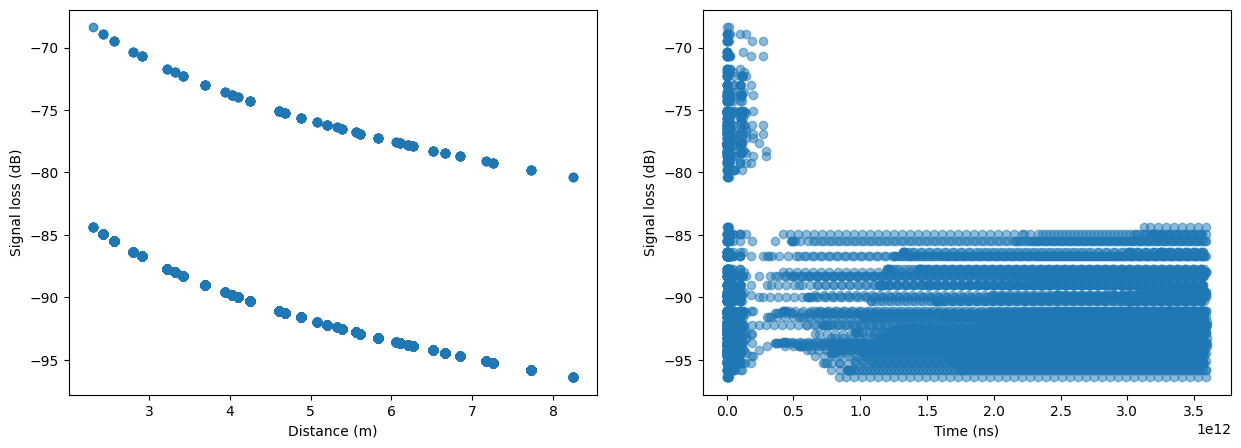

In [24]:
# Merge packet_stats_df with rx_packets_df based on Packet UID
merged_df = pd.merge(packet_stats_df, rx_packets_df, on='Packet UID', how='inner')

%matplotlib inline
# Plot signal loss over distance and time
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].scatter(merged_df['Distance'], merged_df['Signal'], alpha=0.5)
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Signal loss (dB)')
ax[1].scatter(merged_df['Time'], merged_df['Signal'], alpha=0.5)
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Signal loss (dB)')
plt.show()

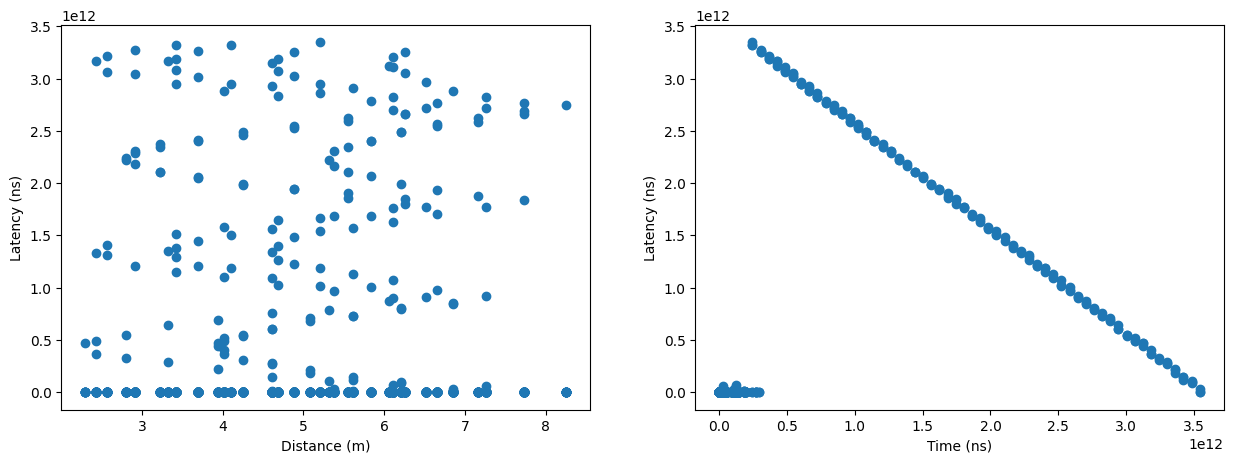

In [25]:
%matplotlib inline
# Plot latency over distance in one plot, and over time in another
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].scatter(packet_stats_df['Distance'], packet_stats_df['Latency'])
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Latency (ns)')
ax[1].scatter(packet_stats_df['First seen at'], packet_stats_df['Latency'])
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Latency (ns)')
plt.show()

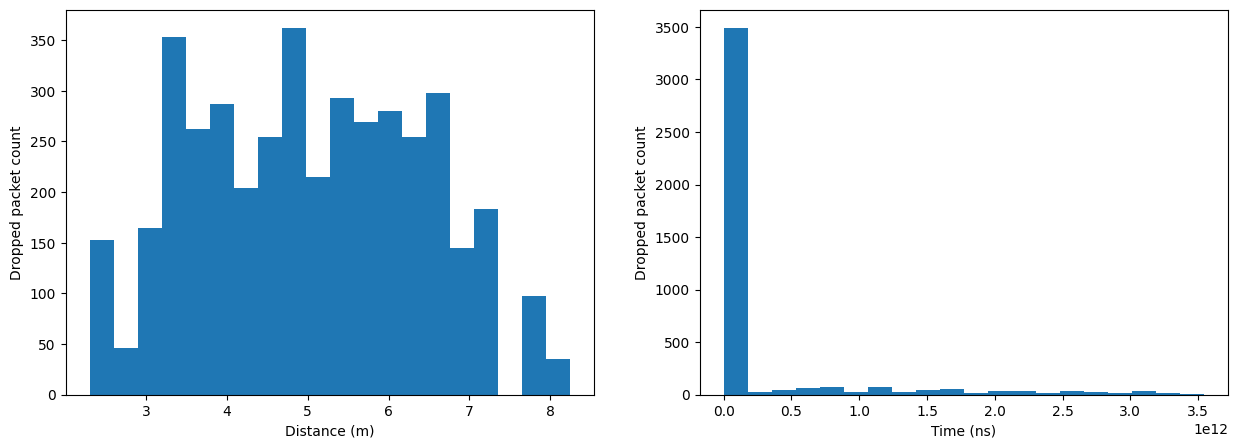

In [26]:
%matplotlib inline
# Plot dropped packets over distance and time
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].hist(packet_stats_df['Distance'], weights=packet_stats_df['Dropped packet count'], bins=20)
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Dropped packet count')
ax[1].hist(packet_stats_df['First seen at'], weights=packet_stats_df['Dropped packet count'], bins=20)
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Dropped packet count')
plt.show()


In [27]:
matplotlib.use("TkAgg")
root = tkinter.Tk()

# Map 'Type' to colors
color_map = {'AP': 'red', 'STA': 'blue'}
colors = node_pos_df['Type'].map(color_map)

fig = plt.figure(dpi=100)

# Create four subplots
ax_node_pos = fig.add_subplot(221, projection='3d')
ax_dropped_packets = fig.add_subplot(222, projection='3d')
ax_latency = fig.add_subplot(223, projection='3d')
ax_signal = fig.add_subplot(224, projection='3d')

# Plot scatter on first subplot
ax_node_pos.scatter(node_pos_df['x'], node_pos_df['y'], node_pos_df['z'], c=colors)
ax_node_pos.set_title('Node positions')
ax_node_pos.set_xlabel('X (cartesian coord, m)')
ax_node_pos.set_ylabel('Y (cartesian coord, m)')
ax_node_pos.set_zlabel('Z (cartesian coord, m)')

# Plot bars on second subplot, where height is the dropped packet count
dropped_packets_colors = plt.cm.coolwarm(node_statistics_df['Dropped packet count'] / node_statistics_df['Dropped packet count'].max())
ax_dropped_packets.bar3d(node_statistics_df['x'], node_statistics_df['y'], np.zeros(len(node_statistics_df)), .5, .5, node_statistics_df['Dropped packet count'], color=dropped_packets_colors)
ax_dropped_packets.set_title('Dropped packet count')
ax_dropped_packets.set_xlabel('X (cartesian coord, m)')
ax_dropped_packets.set_ylabel('Y (cartesian coord, m)')
ax_dropped_packets.set_zlabel('Dropped packet count')

# Plot bars on third subplot, where height is the average latency
latency_colors = plt.cm.coolwarm(node_statistics_df['Average latency'] / node_statistics_df['Average latency'].max())
ax_latency.bar3d(node_statistics_df['x'], node_statistics_df['y'], np.zeros(len(node_statistics_df)), .5, .5, node_statistics_df['Average latency'], color=latency_colors)
ax_latency.set_title('Average latency')
ax_latency.set_xlabel('X (cartesian coord, m)')
ax_latency.set_ylabel('Y (cartesian coord, m)')
ax_latency.set_zlabel('Latency (ns)')

# Plot bars on fourth subplot, where height is the signal strength
signal_colors = plt.cm.coolwarm(node_statistics_df['Average signal strength'] / node_statistics_df['Average signal strength'].max())
ax_signal.bar3d(node_statistics_df['x'], node_statistics_df['y'], np.zeros(len(node_statistics_df)), .5, .5, node_statistics_df['Average signal strength'], color=signal_colors)
ax_signal.set_title('Signal strength')
ax_signal.set_xlabel('X (cartesian coord, m)')
ax_signal.set_ylabel('Y (cartesian coord, m)')
ax_signal.set_zlabel('Signal strength (dB)')
ax_signal.set_zlim(-100, -70)

# Sync the view limits
ax_node_pos.set_xlim(node_pos_df['x'].min(), node_pos_df['x'].max())
ax_node_pos.set_ylim(node_pos_df['y'].min(), node_pos_df['y'].max())
ax_dropped_packets.set_xlim(node_pos_df['x'].min(), node_pos_df['x'].max())
ax_dropped_packets.set_ylim(node_pos_df['y'].min(), node_pos_df['y'].max())
ax_latency.set_xlim(node_pos_df['x'].min(), node_pos_df['x'].max())
ax_latency.set_ylim(node_pos_df['y'].min(), node_pos_df['y'].max())

# Create canvas and toolbar
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.draw()
toolbar = NavigationToolbar2Tk(canvas, root)
toolbar.update()
canvas.get_tk_widget().pack(side=tkinter.TOP, fill=tkinter.BOTH, expand=1)

# Function to sync rotation
def on_rotate(event):
    axes = [ax_node_pos, ax_dropped_packets, ax_latency, ax_signal]
    if event.inaxes in axes:
        # Get the current elevation and azimuth from the active axis
        elev = event.inaxes.elev
        azim = event.inaxes.azim
        
        # Update all other axes except the active one and unused one
        for ax in axes:
            if ax != event.inaxes:
                ax.view_init(elev=elev, azim=azim)
        
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', on_rotate)

tkinter.mainloop()